In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data/processed/nba_model_data_clustered.csv')
print(f"Loaded: {df.shape}")

Loaded: (6567, 82)


In [2]:
features = ['MPG', 'HEIGHT_IN', 'WEIGHT', 'AGE', 'FG3A_RATE', 'FTA_RATE', 'PLUS_MINUS']
target = 'MISSED_GAME_RATE'

# Drop rows with any missing values in features or target
df_model = df[features + [target, 'CLUSTER']].dropna()
print(f"Modeling rows: {len(df_model)} (dropped {len(df) - len(df_model)})")

X = df_model[features]
y = df_model[target]

# One-hot encode position if available
if 'POSITION_GROUP' in df.columns:
    pos = pd.get_dummies(df.loc[df_model.index, 'POSITION_GROUP'], prefix='POS', drop_first=True)
    X = pd.concat([X.reset_index(drop=True), pos.reset_index(drop=True)], axis=1)

# Cluster dummies for Model 4
cluster_dummies = pd.get_dummies(df_model['CLUSTER'], prefix='C', drop_first=True)

print(f"X shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Modeling rows: 6471 (dropped 96)
X shape: (6471, 10)
Features: ['MPG', 'HEIGHT_IN', 'WEIGHT', 'AGE', 'FG3A_RATE', 'FTA_RATE', 'PLUS_MINUS', 'POS_Forward', 'POS_Guard', 'POS_Unknown']


In [3]:
os.makedirs('results', exist_ok=True)

univariate_results = []
for col in features:
    X_col = sm.add_constant(df_model[col])
    model = sm.OLS(y, X_col).fit()
    mse = mean_squared_error(y, model.predict(X_col))
    univariate_results.append({
        'Feature': col,
        'Slope': model.params[col],
        'P_Value': model.pvalues[col],
        'R2': model.rsquared,
        'MSE': mse
    })

uni_df = pd.DataFrame(univariate_results).sort_values('P_Value')
print(uni_df.round(4).to_string(index=False))
uni_df.to_csv('results/univariate_results.csv', index=False)
print("\nSaved results/univariate_results.csv")

   Feature   Slope  P_Value     R2    MSE
       MPG -0.0163   0.0000 0.3468 0.0405
PLUS_MINUS -0.0210   0.0000 0.0583 0.0584
       AGE -0.0036   0.0000 0.0040 0.0618
    WEIGHT -0.0004   0.0008 0.0017 0.0620
 FG3A_RATE  0.0380   0.0064 0.0012 0.0620
  FTA_RATE -0.0486   0.0265 0.0008 0.0620
 HEIGHT_IN  0.0001   0.8932 0.0000 0.0621

Saved results/univariate_results.csv


In [6]:
X = X.reset_index(drop=True).astype(float)
y = y.reset_index(drop=True)
cluster_dummies = cluster_dummies.reset_index(drop=True)

X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())
ols_mse = mean_squared_error(y, ols_model.predict(X_const))
print(f"\nOLS MSE: {ols_mse:.4f}")

                            OLS Regression Results                            
Dep. Variable:       MISSED_GAME_RATE   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     367.9
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:16:21   Log-Likelihood:                 1269.9
No. Observations:                6471   AIC:                            -2518.
Df Residuals:                    6460   BIC:                            -2443.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6615      0.103      6.403      

In [7]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge.fit(X, y)

ridge_preds = ridge.predict(X)
ridge_mse = mean_squared_error(y, ridge_preds)
print(f"Best alpha: {ridge.alpha_:.4f}")
print(f"Ridge MSE (train): {ridge_mse:.4f}")

Best alpha: 4.7149
Ridge MSE (train): 0.0395


In [8]:
X_cluster = sm.add_constant(cluster_dummies.astype(float))
cluster_model = sm.OLS(y, X_cluster).fit()
cluster_mse = mean_squared_error(y, cluster_model.predict(X_cluster))
print(f"Cluster-label OLS R²: {cluster_model.rsquared:.4f}")
print(f"Cluster-label MSE: {cluster_mse:.4f}")

Cluster-label OLS R²: 0.2100
Cluster-label MSE: 0.0490


In [9]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=109)

# Model 1: avg of univariate CV MSEs
uni_cv_mses = []
for col in features:
    scores = cross_val_score(Ridge(alpha=1), df_model[[col]], y, cv=kf, scoring='neg_mean_squared_error')
    uni_cv_mses.append(-scores.mean())
uni_cv_mse = np.mean(uni_cv_mses)

# Model 2: Multivariable OLS (use Ridge with tiny alpha to approximate)
ols_cv = cross_val_score(Ridge(alpha=0.001), X, y, cv=kf, scoring='neg_mean_squared_error')
ols_cv_mse = -ols_cv.mean()

# Model 3: Ridge CV
ridge_cv = cross_val_score(Ridge(alpha=ridge.alpha_), X, y, cv=kf, scoring='neg_mean_squared_error')
ridge_cv_mse = -ridge_cv.mean()

# Model 4: Cluster-label
cluster_cv = cross_val_score(Ridge(alpha=0.001), cluster_dummies.astype(float), y, cv=kf, scoring='neg_mean_squared_error')
cluster_cv_mse = -cluster_cv.mean()

comparison = pd.DataFrame({
    'Model': ['Simple (avg univariate)', 'Multivariable OLS', f'Ridge (alpha={ridge.alpha_:.2f})', 'Cluster-label'],
    'CV_MSE': [uni_cv_mse, ols_cv_mse, ridge_cv_mse, cluster_cv_mse]
}).round(4)

print(comparison.to_string(index=False))
comparison.to_csv('results/model_comparison.csv', index=False)
print("\nSaved results/model_comparison.csv")

                  Model  CV_MSE
Simple (avg univariate)  0.0584
      Multivariable OLS  0.0397
     Ridge (alpha=4.71)  0.0397
          Cluster-label  0.0493

Saved results/model_comparison.csv


Final Model: Ridge (alpha=4.7149)
RMSE: 0.1989
R²:   0.3628

Coefficients:
    Feature  Coefficient
        MPG    -0.015650
POS_Unknown    -0.010044
 PLUS_MINUS    -0.009883
     WEIGHT    -0.000487
        AGE     0.000477
  HEIGHT_IN     0.000527
POS_Forward     0.000574
  POS_Guard     0.002717
  FG3A_RATE     0.042812
   FTA_RATE     0.082486


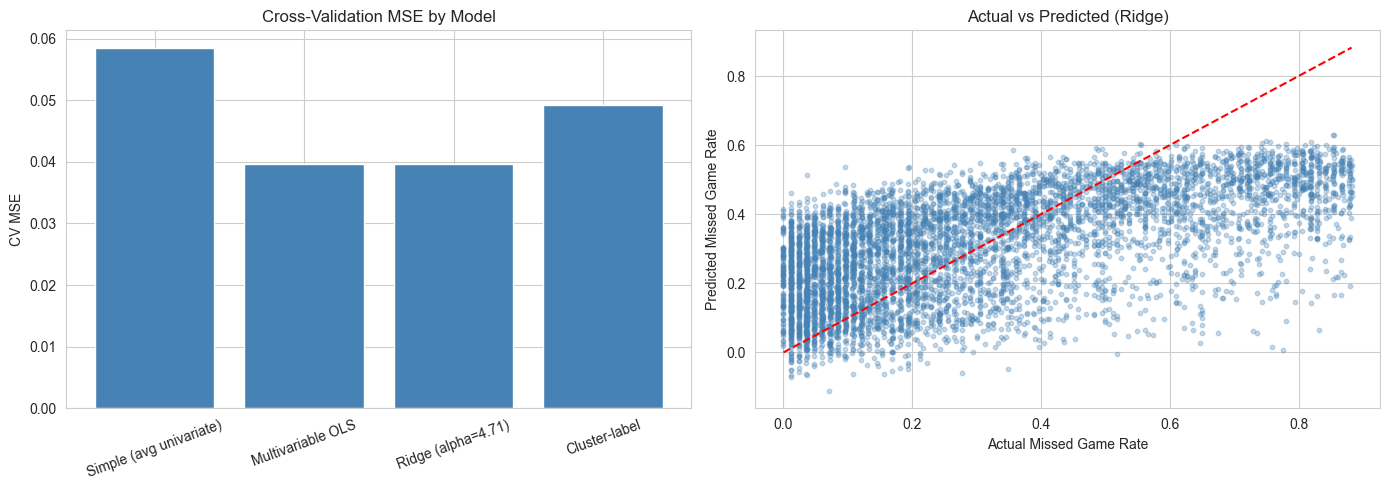

Saved figures/model_results.png


In [11]:
# Refit Ridge on full dataset
final_model = Ridge(alpha=ridge.alpha_)
final_model.fit(X, y)
y_pred = final_model.predict(X)

final_mse = mean_squared_error(y, y_pred)
final_rmse = np.sqrt(final_mse)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
final_r2 = 1 - ss_res/ss_tot

print(f"Final Model: Ridge (alpha={ridge.alpha_:.4f})")
print(f"RMSE: {final_rmse:.4f}")
print(f"R²:   {final_r2:.4f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': final_model.coef_}).sort_values('Coefficient')
print("\nCoefficients:")
print(coef_df.to_string(index=False))
coef_df.to_csv('results/final_model_params.csv', index=False)

# Figure 1: CV MSE comparison
os.makedirs('figures', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison['Model'], comparison['CV_MSE'], color='steelblue')
axes[0].set_ylabel('CV MSE')
axes[0].set_title('Cross-Validation MSE by Model')
axes[0].tick_params(axis='x', rotation=20)

# Figure 2: Actual vs Predicted
axes[1].scatter(y, y_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1.5)
axes[1].set_xlabel('Actual Missed Game Rate')
axes[1].set_ylabel('Predicted Missed Game Rate')
axes[1].set_title('Actual vs Predicted (Ridge)')

plt.tight_layout()
plt.savefig('figures/model_results.png', dpi=150)
plt.show()
print("Saved figures/model_results.png")